In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
df = pd.read_csv('Dataset_Day3.csv')
df['distance'] = np.sqrt((df['dropoff_latitude'] - df['pickup_latitude'])**2 + (df['dropoff_longitude'] - df['pickup_longitude'])**2)
# Check basic statistics of the new distance column
print("\nDistance statistics:")
print(df['distance'].describe())


Distance statistics:
count    199999.000000
mean          0.256968
std           9.216476
min           0.000000
25%           0.012432
50%           0.021489
75%           0.038335
max        2434.714983
Name: distance, dtype: float64


In [4]:
def remove_outliers(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] >= lower_bound) & (df[column] <= upper_bound)]
df_clean = remove_outliers(df, 'fare_amount')
df_clean = remove_outliers(df_clean, 'passenger_count')
df_clean = remove_outliers(df_clean, 'distance')
original_keys = set(df['key'])
remaining_keys = set(df_clean['key'])
removed_keys = original_keys - remaining_keys
print(f"Removed {len(removed_keys)} outliers")

Removed 45195 outliers


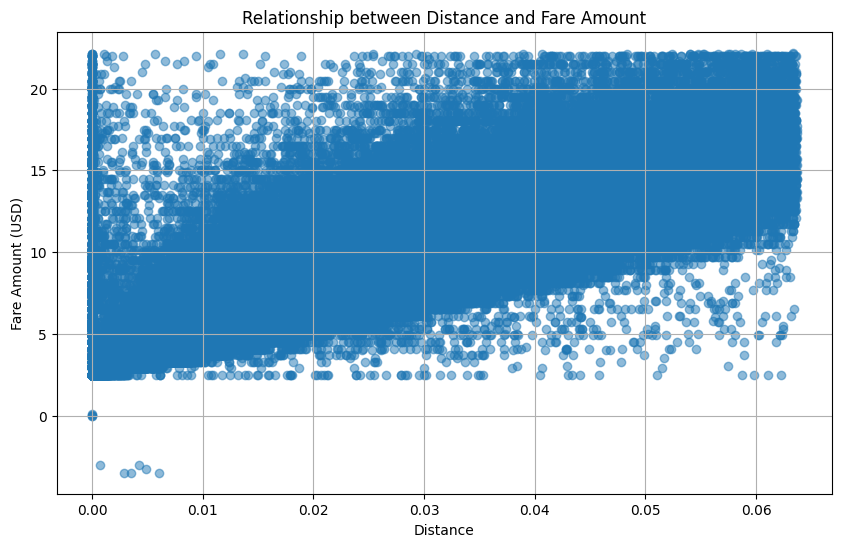

Correlation coefficient between distance and fare amount: 0.76


In [5]:
plt.figure(figsize=(10, 6))
plt.scatter(df_clean['distance'], df_clean['fare_amount'], alpha=0.5)
plt.title('Relationship between Distance and Fare Amount')
plt.xlabel('Distance')
plt.ylabel('Fare Amount (USD)')
plt.grid(True)
plt.show()
correlation = df_clean['distance'].corr(df_clean['fare_amount'])
print(f"Correlation coefficient between distance and fare amount: {correlation:.2f}")